<a href="https://colab.research.google.com/github/amirmoradzadeh/High-speed-Rails/blob/main/HSR_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Amirhossein Moradzadeh
# ====================== 1. IMPORTS ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

try:
    import joblib
except ImportError:
    !pip install joblib
    import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# 2.3–2.4 Data Sources, Acquisition and Cleaning
# ====================== 2. DATA LOADING & CLEANING ======================

file_path = 'Property prices dataset(24).xlsx'
df = pd.read_excel('/content/Property prices dataset(24).xlsx', sheet_name='Panel data set completo')

df.columns = ['YEAR', 'City', 'Station', 'Residential_housing', 'Affordable_housing',
              'Residential_Box', 'Commercial_warehouses', 'Tertiary_offices',
              'Productive_warehouses', 'Productive_Labs']

df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce')
numeric_cols = ['Residential_housing', 'Affordable_housing', 'Residential_Box',
                'Commercial_warehouses', 'Tertiary_offices', 'Productive_warehouses', 'Productive_Labs']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Residential_housing']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print("\nStation frequency:\n", df['Station'].value_counts())

Dataset shape: (224, 10)

Station frequency:
 Station
Centrale           73
Garibaldi          19
Termini            19
Novella            19
Tiburtina          19
Santa Lucia        19
Porta Garibaldi    18
Porta Susa         14
Afragola           12
Mediopadana        11
porta garibaldi     1
Name: count, dtype: int64


Table 3.2: High-Speed Rail Station Opening Timeline
        Station  Opening_Year
        Termini          1992
        Novella          1992
Porta Garibaldi          2006
    Santa Lucia          2007
       Centrale          2008
      Garibaldi          2009
     Porta Susa          2009
      Tiburtina          2011
    Mediopadana          2013
       Afragola          2017


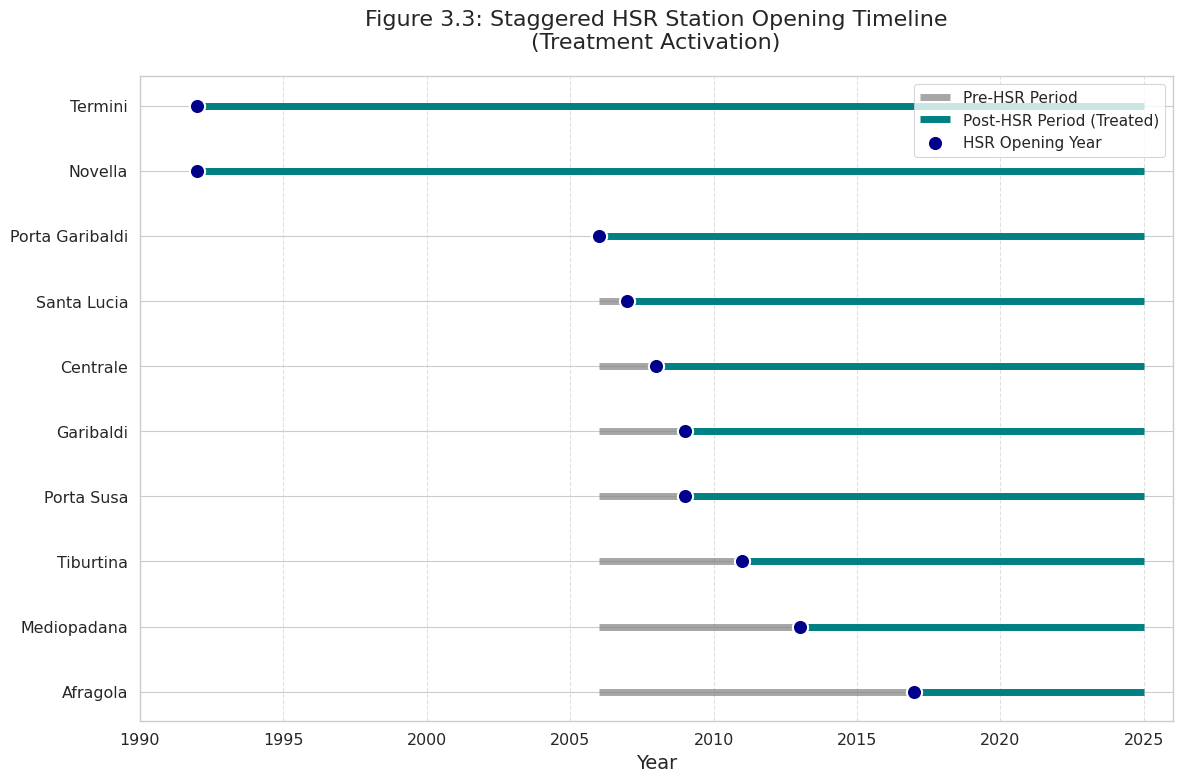


 Table 3.2 and Figure 3.3 generated and saved successfully.
This timeline underpins the staggered treatment design (post_HSR dummy).
Stations with Opening_Year = NaN remain untreated (control) throughout the sample.
post_HSR distribution:
 post_HSR
1    192
0     32
Name: count, dtype: int64


In [ ]:
# 2.5 Feature Engineering – post_HSR Dummy
# ====================== 2.5 FEATURE ENGINEERING ======================
hsr_opening = {
    'Garibaldi': 2009, 'Afragola': 2017, 'Centrale': 2008, 'Termini': 1992,
    'Tiburtina': 2011, 'Novella': 1992, 'Mediopadana': 2013,
    'Porta Garibaldi': 2006, 'Porta Susa': 2009, 'Santa Lucia': 2007 }
# Create timeline DataFrame
timeline_df = pd.DataFrame(list(hsr_opening.items()),
                           columns=['Station', 'Opening_Year'])

# Sort chronologically (earliest first)
timeline_df_sorted = timeline_df.sort_values('Opening_Year',
                                             na_position='last').reset_index(drop=True)

# ====================== Table 3.2 ======================
print("Table 3.2: High-Speed Rail Station Opening Timeline")
print(timeline_df_sorted.to_string(index=False))

# ====================== Figure 3.3: Staggered Timeline  ======================
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

y_pos = np.arange(len(timeline_df_sorted))
# Pre-HSR period (gray)
plt.hlines(y=y_pos,
           xmin=2006,
           xmax=timeline_df_sorted['Opening_Year'].fillna(2025),
           color='gray', linewidth=5, alpha=0.7, label='Pre-HSR Period')

# Post-HSR period (teal)
plt.hlines(y=y_pos,
           xmin=timeline_df_sorted['Opening_Year'].fillna(2025),
           xmax=2025,
           color='teal', linewidth=5, label='Post-HSR Period (Treated)')

# Exact opening year markers
treated = timeline_df_sorted['Opening_Year'].notna()
plt.scatter(timeline_df_sorted.loc[treated, 'Opening_Year'],
            y_pos[treated],
            color='darkblue', s=120, zorder=5,
            label='HSR Opening Year', marker='o', edgecolors='white', linewidth=1.5)

# Formatting
plt.yticks(y_pos, timeline_df_sorted['Station'])
plt.xlabel('Year', fontsize=14)
plt.title('Figure 3.3: Staggered HSR Station Opening Timeline\n(Treatment Activation)',
          fontsize=16, pad=20)
plt.xlim(1990, 2026)
plt.legend(loc='best', fontsize=11)
plt.gca().invert_yaxis()          # Top = earliest stations
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Figure_3.3_HSR_Timeline.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_3.3_HSR_Timeline.pdf', bbox_inches='tight')

plt.show()

print("\n Table 3.2 and Figure 3.3 generated and saved successfully.")
print("This timeline underpins the staggered treatment design (post_HSR dummy).")
print("Stations with Opening_Year = NaN remain untreated (control) throughout the sample.")

df['hsr_opening_year'] = df['Station'].map(hsr_opening)
df['post_HSR'] = 0
mask = (df['hsr_opening_year'].notna()) & (df['YEAR'] > df['hsr_opening_year'])
df.loc[mask, 'post_HSR'] = 1
df.drop('hsr_opening_year', axis=1, inplace=True)

print("post_HSR distribution:\n", df['post_HSR'].value_counts())

In [ ]:
# 2.6–2.7 Model Selection, Training and Hyperparameter Considerations
# ====================== 4. MODEL TRAINING ======================

categorical_features = ['City', 'Station']
numeric_features = ['YEAR', 'post_HSR']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', SimpleImputer(strategy='median'), numeric_features)
    ])

X = df[categorical_features + numeric_features]
y = df['Residential_housing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (Primary)': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1)
}

results = []
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({'Model': name, 'R²': round(r2, 3), 'RMSE': round(rmse, 0)})

    # ذخیره بهترین مدل
    if name == 'Random Forest (Primary)':
        joblib.dump(pipeline, 'best_rf_model.pkl')
        print(" Best RF model saved as 'best_rf_model.pkl'")

print("\n=== Model Performance (Levels) ===")
display(pd.DataFrame(results))

 Best RF model saved as 'best_rf_model.pkl'

=== Model Performance (Levels) ===


,Model,R²,RMSE
0,Linear Regression,0.744,581.0
1,Random Forest (Primary),0.858,433.0
2,Gradient Boosting,0.872,412.0
3,SVR,0.152,1059.0


In [ ]:
## 2.10 Robustness Checks – Log Transformation of Target Variable
# ====================== ROBUSTNESS: LOG TRANSFORMATION ======================

df['log_price'] = np.log1p(df['Residential_housing'])
y_log = df['log_price']

X_train_raw, X_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42, shuffle=True
)

log_results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train_raw, y_train_log)
    y_pred_log = pipe.predict(X_test_raw)

    r2_log = r2_score(y_test_log, y_pred_log)
    y_pred_orig = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test_log)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

    log_results.append({
        'Model': name,
        'R² (Log Scale)': round(r2_log, 3),
        'RMSE (Original €/m²)': round(rmse_orig, 0)
    })

print("=== Performance with Log-Transformed Target ===")
display(pd.DataFrame(log_results))


=== Performance with Log-Transformed Target ===


,Model,R² (Log Scale),RMSE (Original €/m²)
0,Linear Regression,0.842,601.0
1,Random Forest (Primary),0.906,372.0
2,Gradient Boosting,0.889,438.0
3,SVR,0.866,465.0


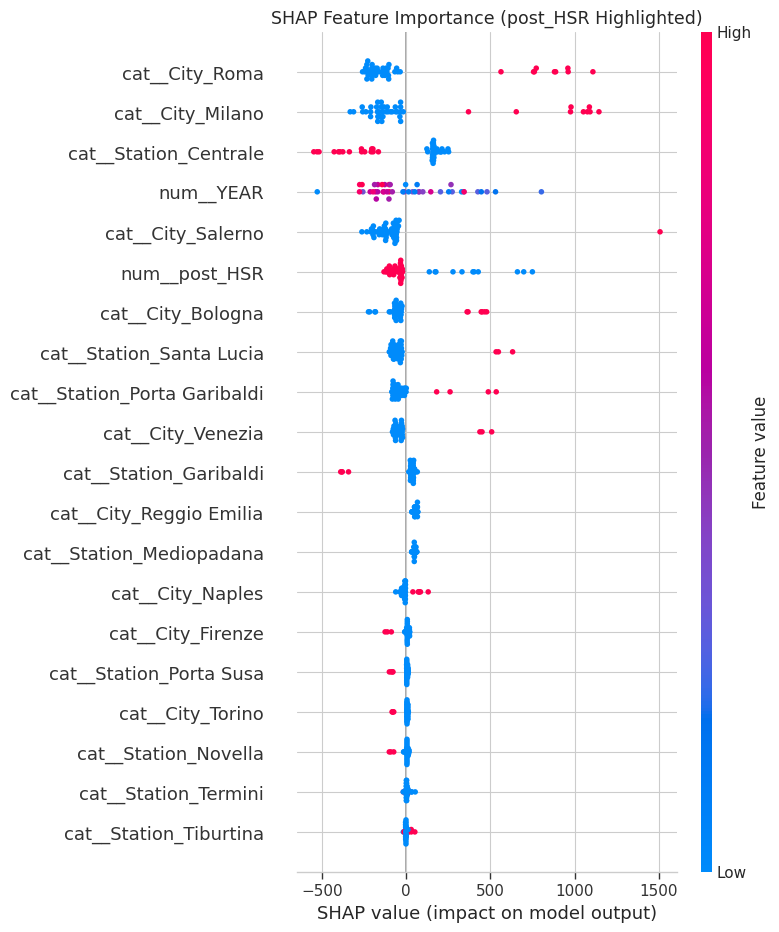

In [ ]:
## 2.9 Model Interpretation Techniques – SHAP Values
# ====================== INTERPRETATION – SHAP ======================
best_pipeline = joblib.load('best_rf_model.pkl')
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
rf_model = best_pipeline.named_steps['model']

X_test_transformed = preprocessor_fitted.transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=preprocessor_fitted.get_feature_names_out(),
                  show=False)
plt.title("SHAP Feature Importance (post_HSR Highlighted)")
plt.tight_layout()
plt.savefig("SHAP_Summary.png", dpi=300)
plt.show()

In [ ]:
## 3.6 Out-of-Sample Predictions for 2026
# ====================== 2026 PREDICTIONS ======================

future_df = X_test.copy()
future_df['YEAR'] = 2026
future_df['post_HSR'] = 1

future_pred = best_pipeline.predict(future_df)

future_pred_df = pd.DataFrame({
    'Station': X_test['Station'],
    'Predicted_Price_2026': np.round(future_pred, 0)
}).groupby('Station').mean().round(0)

print("2026 Average Predicted Residential Prices (€/m²):")
display(future_pred_df)

future_pred_df.to_csv("Predictions_2026.csv")
print("Predictions saved to 'Predictions_2026.csv'")

2026 Average Predicted Residential Prices (€/m²):


,Predicted_Price_2026
Station,
Afragola,2990.0
Centrale,2846.0
Garibaldi,2366.0
Novella,3179.0
Porta Garibaldi,5779.0
Porta Susa,2618.0
Santa Lucia,3664.0
Termini,3413.0
Tiburtina,3812.0


Predictions saved to 'Predictions_2026.csv'


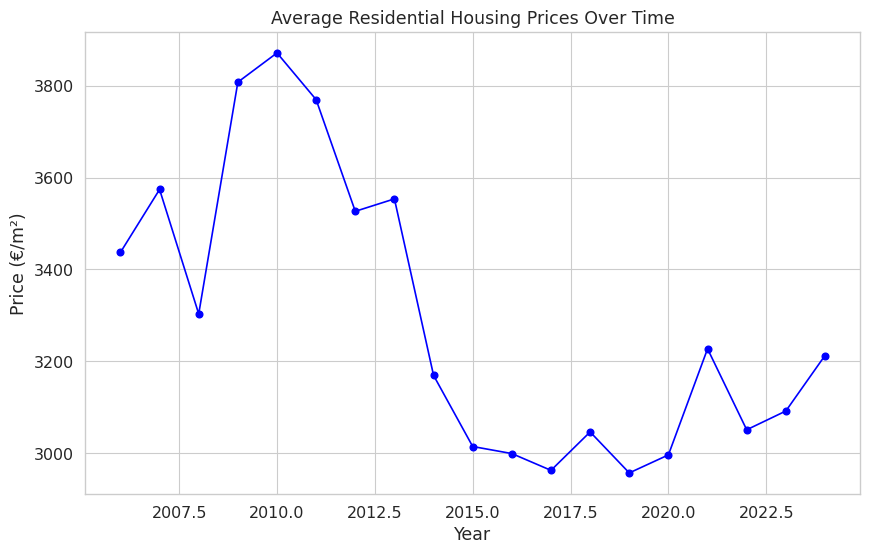

In [ ]:
# Line plot: Average prices over time
year_avg = df.groupby('YEAR')['Residential_housing'].mean()
plt.figure(figsize=(10, 6))
plt.plot(year_avg.index, year_avg.values, marker='o', color='blue')
plt.title('Average Residential Housing Prices Over Time')
plt.xlabel('Year')
plt.ylabel('Price (€/m²)')
plt.grid(True)
plt.savefig('yearly_prices_line.png')

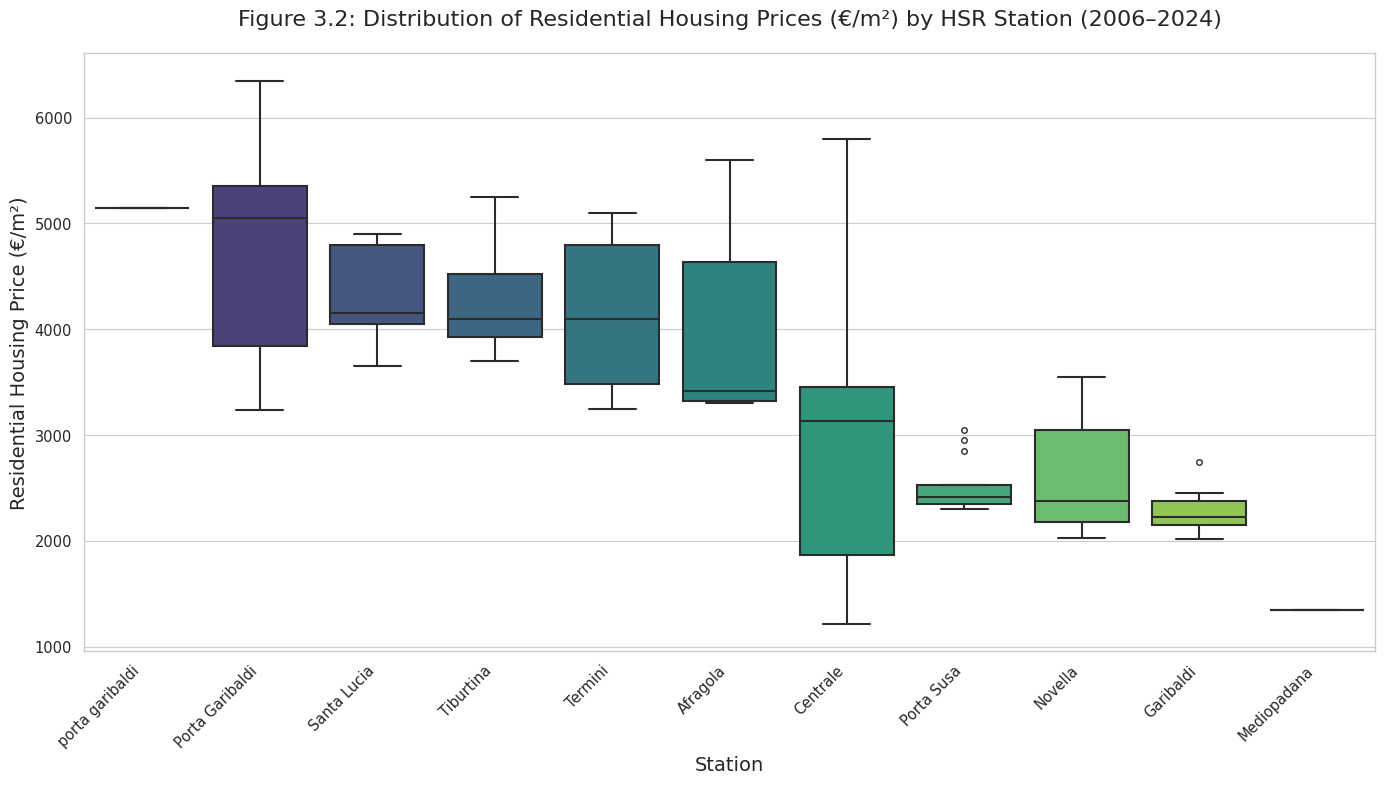

Figure 3.2 generated and saved as PNG/PDF for thesis use.
Stations ordered by descending median price for better visual comparison.


In [ ]:
# Ensure clean data for the target variable
df_plot = df.dropna(subset=['Residential_housing', 'Station'])

# Optional: Sort stations by median price for clearer visual hierarchy (high to low)
station_order = df_plot.groupby('Station')['Residential_housing'].median().sort_values(ascending=False).index

# Set style for professional/thesis-quality look that works well in documents
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Create the boxplot
sns.boxplot(
    x='Station',
    y='Residential_housing',
    data=df_plot,
    order=station_order,
    palette="viridis",
    linewidth=1.5,
    fliersize=4
)

# Customize labels and title
plt.title('Figure 3.2: Distribution of Residential Housing Prices (€/m²) by HSR Station (2006–2024)',
          fontsize=16, pad=20)
plt.xlabel('Station', fontsize=14)
plt.ylabel('Residential Housing Price (€/m²)', fontsize=14)

# Rotate x-labels for readability (many stations)
plt.xticks(rotation=45, ha='right')

# Tight layout to prevent label cutoff
plt.tight_layout()

# Optional: Save high-resolution figure for thesis insertion
plt.savefig('Figure_3.2_Boxplot_Residential_Prices_by_Station.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_3.2_Boxplot_Residential_Prices_by_Station.pdf', bbox_inches='tight')  # Vector format for LaTeX

# Display in notebook
plt.show()

print("Figure 3.2 generated and saved as PNG/PDF for thesis use.")
print("Stations ordered by descending median price for better visual comparison.")

Table 3.2: High-Speed Rail Station Opening Timeline
        Station  Opening_Year
        Termini          1992
        Novella          1992
Porta Garibaldi          2006
    Santa Lucia          2007
       Centrale          2008
      Garibaldi          2009
     Porta Susa          2009
      Tiburtina          2011
    Mediopadana          2013
       Afragola          2017


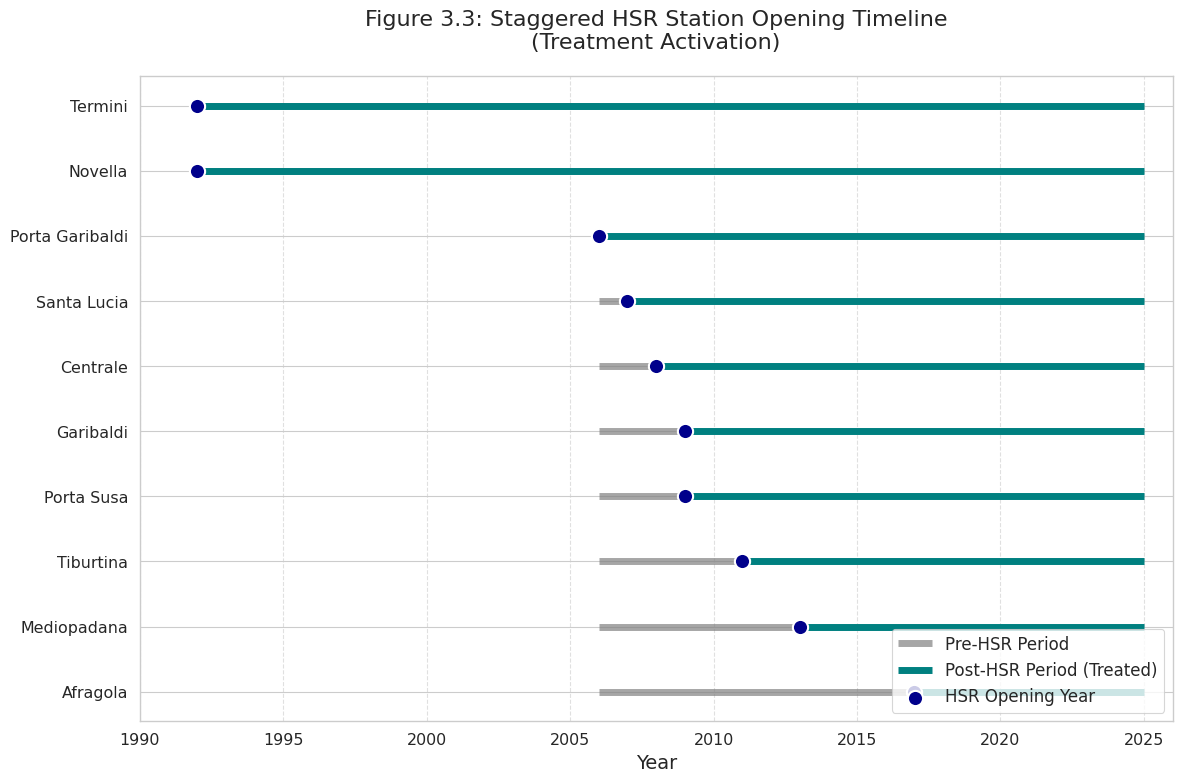


 Table 3.2 and Figure 3.3 generated and saved successfully.
This timeline underpins the staggered treatment design (post_HSR dummy).
Stations with Opening_Year = NaN remain untreated (control) throughout the sample.
post_HSR distribution:
 post_HSR
1    192
0     32
Name: count, dtype: int64


In [ ]:
hsr_opening = {
    'Garibaldi': 2009, 'Afragola': 2017, 'Centrale': 2008, 'Termini': 1992,
    'Tiburtina': 2011, 'Novella': 1992, 'Mediopadana': 2013,
    'Porta Garibaldi': 2006, 'Porta Susa': 2009, 'Santa Lucia': 2007 }
# Create timeline DataFrame
timeline_df = pd.DataFrame(list(hsr_opening.items()),
                           columns=['Station', 'Opening_Year'])

# Sort chronologically (earliest first)
timeline_df_sorted = timeline_df.sort_values('Opening_Year',
                                             na_position='last').reset_index(drop=True)

# ====================== Table 3.2 ======================
print("Table 3.2: High-Speed Rail Station Opening Timeline")
print(timeline_df_sorted.to_string(index=False))

# ====================== Figure 3.3: Staggered Timeline (Gantt-style) ======================
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

y_pos = np.arange(len(timeline_df_sorted))
# Pre-HSR period (gray)
plt.hlines(y=y_pos,
           xmin=2006,
           xmax=timeline_df_sorted['Opening_Year'].fillna(2025),
           color='gray', linewidth=5, alpha=0.7, label='Pre-HSR Period')

# Post-HSR period (teal)
plt.hlines(y=y_pos,
           xmin=timeline_df_sorted['Opening_Year'].fillna(2025),
           xmax=2025,
           color='teal', linewidth=5, label='Post-HSR Period (Treated)')

# Exact opening year markers
treated = timeline_df_sorted['Opening_Year'].notna()
plt.scatter(timeline_df_sorted.loc[treated, 'Opening_Year'],
            y_pos[treated],
            color='darkblue', s=120, zorder=5,
            label='HSR Opening Year', marker='o', edgecolors='white', linewidth=1.5)

# Formatting
plt.yticks(y_pos, timeline_df_sorted['Station'])
plt.xlabel('Year', fontsize=14)
plt.title('Figure 3.3: Staggered HSR Station Opening Timeline\n(Treatment Activation)',
          fontsize=16, pad=20)
plt.xlim(1990, 2026)
plt.legend(loc='lower right', fontsize=12)
plt.gca().invert_yaxis()          # Top = earliest stations
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('Figure_3.3_HSR_Timeline.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_3.3_HSR_Timeline.pdf', bbox_inches='tight')

plt.show()

print("\n Table 3.2 and Figure 3.3 generated and saved successfully.")
print("This timeline underpins the staggered treatment design (post_HSR dummy).")
print("Stations with Opening_Year = NaN remain untreated (control) throughout the sample.")

df['hsr_opening_year'] = df['Station'].map(hsr_opening)
df['post_HSR'] = 0
mask = (df['hsr_opening_year'].notna()) & (df['YEAR'] > df['hsr_opening_year'])
df.loc[mask, 'post_HSR'] = 1
df.drop('hsr_opening_year', axis=1, inplace=True)

print("post_HSR distribution:\n", df['post_HSR'].value_counts())

Table 3.5: Descriptive Statistics for Residential Housing Prices (€/m²)
Analytical Sample: n = 224 observations (2006–2024)

           Statistic Value (€/m²)                                       Interpretation
           Count (n)          224            Total number of station-year observations
                Mean     3,273.87                   Average residential property price
  Standard Deviation     1,181.80       Dispersion of prices across stations and years
             Minimum     1,215.00                          Lowest observed zonal price
25th Percentile (Q1)     2,375.00                                       Lower quartile
              Median     3,329.17                Central tendency (robust to outliers)
75th Percentile (Q3)     4,050.00                                       Upper quartile
             Maximum     6,350.00                         Highest observed zonal price
            Skewness        0.135            Positive skew (right-tailed distribution)
     

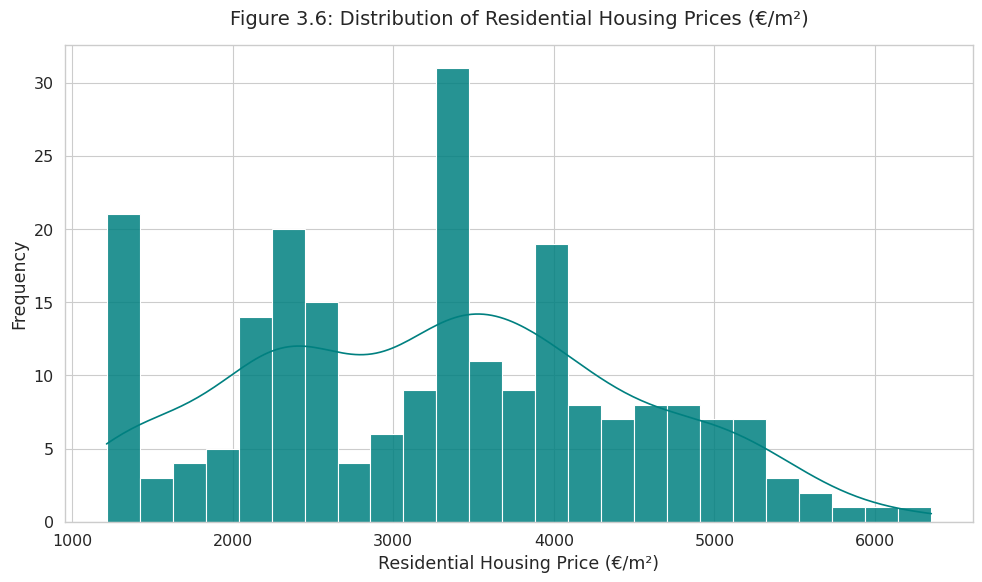


Figure 3.6 generated and saved successfully.


In [ ]:
# ====================== Table 3.5: Descriptive Statistics for Residential Housing Prices ======================

import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

df_stats = df.dropna(subset=['Residential_housing']).copy()

desc = df_stats['Residential_housing'].describe()

#  Skewness  Kurtosis
skewness = round(skew(df_stats['Residential_housing']), 3)
kurt = round(kurtosis(df_stats['Residential_housing']), 3)

stats_table = pd.DataFrame({
    'Statistic': [
        'Count (n)',
        'Mean',
        'Standard Deviation',
        'Minimum',
        '25th Percentile (Q1)',
        'Median',
        '75th Percentile (Q3)',
        'Maximum',
        'Skewness',
        'Kurtosis'
    ],
    'Value (€/m²)': [
        f"{int(desc['count']):,}",
        f"{desc['mean']:,.2f}",
        f"{desc['std']:,.2f}",
        f"{desc['min']:,.2f}",
        f"{desc['25%']:,.2f}",
        f"{desc['50%']:,.2f}",
        f"{desc['75%']:,.2f}",
        f"{desc['max']:,.2f}",
        f"{skewness:.3f}",
        f"{kurt:.3f}"
    ],
    'Interpretation': [
        'Total number of station-year observations',
        'Average residential property price',
        'Dispersion of prices across stations and years',
        'Lowest observed zonal price',
        'Lower quartile',
        'Central tendency (robust to outliers)',
        'Upper quartile',
        'Highest observed zonal price',
        'Positive skew (right-tailed distribution)',
        'Leptokurtic distribution (heavier tails than normal)'
    ]
})

print("Table 3.5: Descriptive Statistics for Residential Housing Prices (€/m²)")
print(f"Analytical Sample: n = {int(desc['count']):,} observations (2006–2024)\n")
print(stats_table.to_string(index=False))

stats_table.to_csv('Table_3.5_Descriptive_Statistics.csv', index=False)
print("\nTable 3.5 saved successfully as 'Table_3.5_Descriptive_Statistics.csv'")

# ====================== Figure 3.6: Price Distribution ======================

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(df_stats['Residential_housing'],
             kde=True,
             bins=25,
             color='teal',
             alpha=0.85)

plt.title('Figure 3.6: Distribution of Residential Housing Prices (€/m²)',
          fontsize=14, pad=15)
plt.xlabel('Residential Housing Price (€/m²)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('Figure_3.6_Price_Distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_3.6_Price_Distribution.pdf', bbox_inches='tight')
plt.show()

print("\nFigure 3.6 generated and saved successfully.")

 Best Model: Gradient Boosting (Test R² = 0.8717)
All models fitted successfully with proper preprocessing.


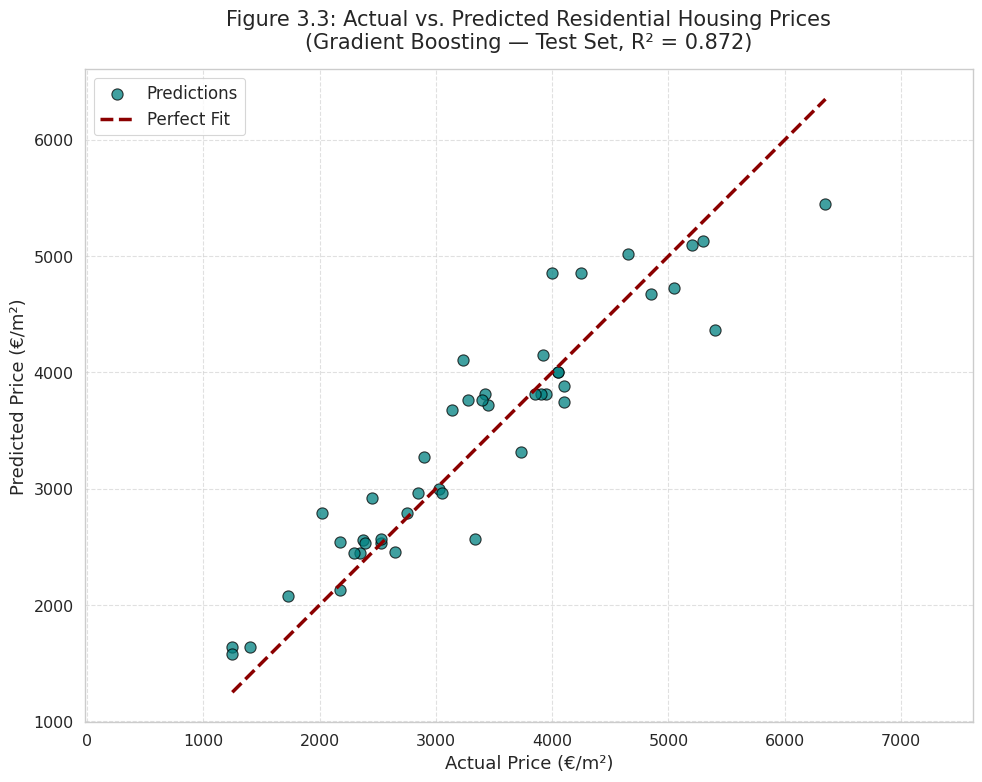

In [ ]:

# ------------------- Preprocessor -------------------
categorical_features = ['City', 'Station']
numeric_features = ['YEAR', 'post_HSR']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', SimpleImputer(strategy='median'), numeric_features)
    ])

# ------------------- Pipeline -------------------
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (Primary)': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1)
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    results[name] = round(r2, 6)
    fitted_pipelines[name] = pipeline

best_name = max(results, key=results.get)
best_pipeline = fitted_pipelines[best_name]
y_pred_best = best_pipeline.predict(X_test)
best_r2 = results[best_name]

print(f" Best Model: {best_name} (Test R² = {best_r2:.4f})")
print("All models fitted successfully with proper preprocessing.")

# ====================== Figure 3.3: Actual vs. Predicted ======================
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

plt.scatter(y_test, y_pred_best, alpha=0.75, color='teal', edgecolor='black', s=65, label='Predictions')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', lw=2.5, ls='--', label='Perfect Fit')

plt.title(f'Figure 3.3: Actual vs. Predicted Residential Housing Prices\n'
          f'({best_name} — Test Set, R² = {best_r2:.3f})', fontsize=15, pad=15)
plt.xlabel('Actual Price (€/m²)', fontsize=13)
plt.ylabel('Predicted Price (€/m²)', fontsize=13)
plt.axis('equal')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.6, ls='--')

plt.tight_layout()
plt.savefig(f'Figure_3.3_Actual_vs_Predicted_{best_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'Figure_3.3_Actual_vs_Predicted_{best_name.replace(" ", "_")}.pdf', bbox_inches='tight')
plt.show()



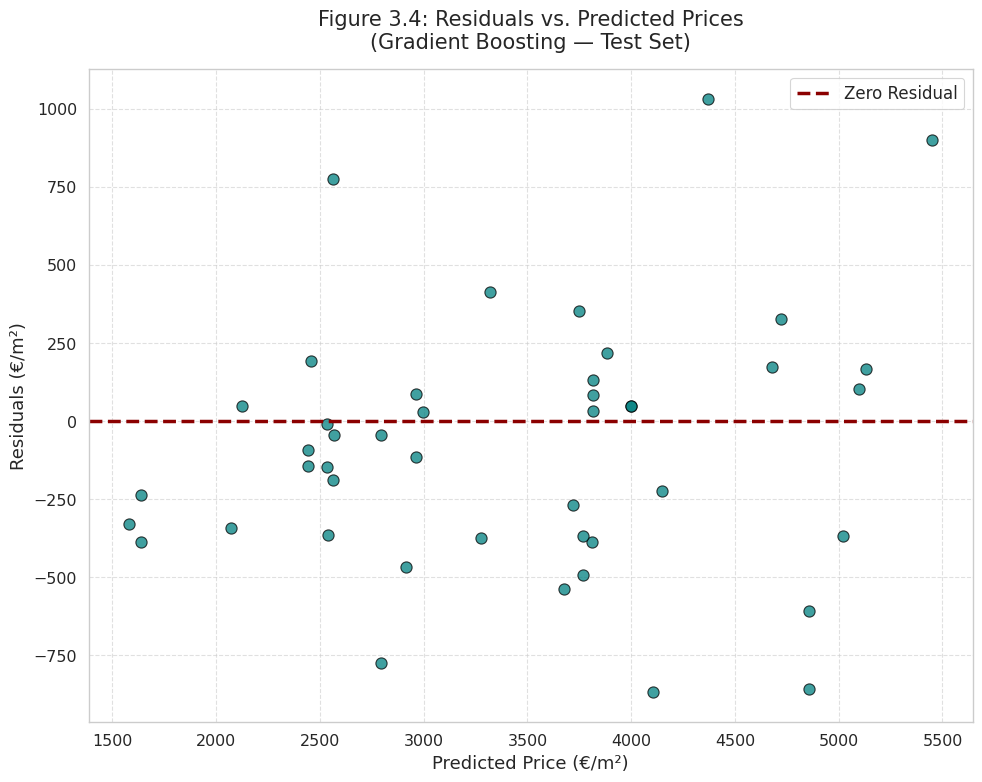


Figures 3.3 and 3.4 generated and saved using Gradient Boosting.


In [ ]:
# ====================== Figure 3.4: Residuals vs. Predicted ======================
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 8))
plt.scatter(y_pred_best, residuals, alpha=0.75, color='teal', edgecolor='black', s=65)
plt.axhline(y=0, color='darkred', lw=2.5, ls='--', label='Zero Residual')

plt.title(f'Figure 3.4: Residuals vs. Predicted Prices\n'
          f'({best_name} — Test Set)', fontsize=15, pad=15)
plt.xlabel('Predicted Price (€/m²)', fontsize=13)
plt.ylabel('Residuals (€/m²)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.6, ls='--')

plt.tight_layout()
plt.savefig(f'Figure_3.4_Residuals_vs_Predicted_{best_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'Figure_3.4_Residuals_vs_Predicted_{best_name.replace(" ", "_")}.pdf', bbox_inches='tight')
plt.show()

print(f"\nFigures 3.3 and 3.4 generated and saved using {best_name}.")

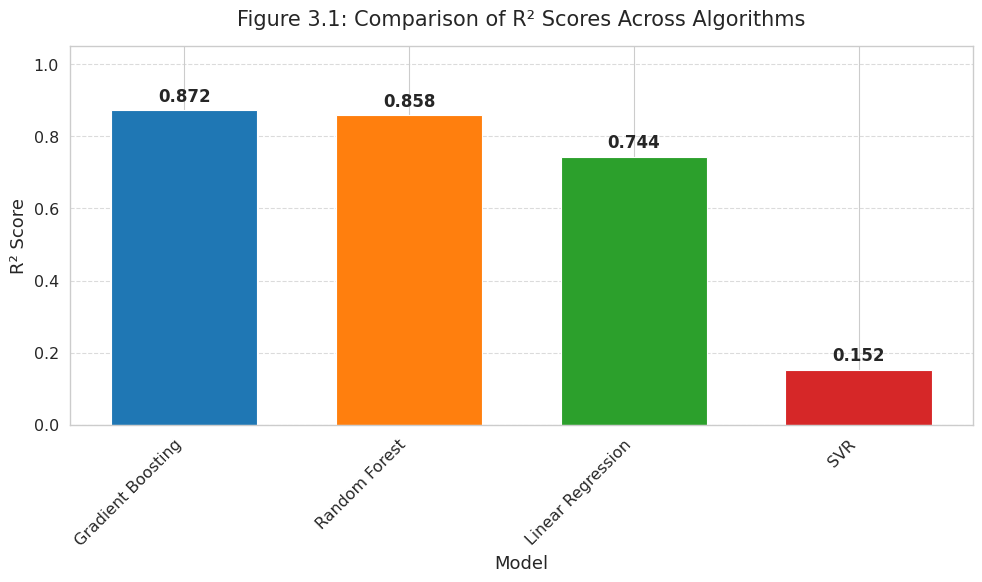

 Figure 3.1 successfully generated and saved.


In [ ]:


# ------------------- Preprocessor -------------------
categorical_features = ['City', 'Station']
numeric_features = ['YEAR', 'post_HSR']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', SimpleImputer(strategy='median'), numeric_features)
    ])

# ------------------- Models -------------------
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1)
}

results = []
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'R²': round(r2, 3)})

results_df = pd.DataFrame(results)

# descending
results_df = results_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = plt.bar(results_df['Model'], results_df['R²'], color=colors[:len(results_df)], width=0.65)

plt.title('Figure 3.1: Comparison of R² Scores Across Algorithms', fontsize=15, pad=15)
plt.xlabel('Model', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015,
             f'{height:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('Figure_3.1_R2_Comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_3.1_R2_Comparison.pdf', bbox_inches='tight')
plt.show()

print(" Figure 3.1 successfully generated and saved.")

In [ ]:
# ====================== Table 4.2: Full Ranked Permutation Feature Importance ======================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# ------------------- Preprocessor -------------------
categorical_features = ['City', 'Station']
numeric_features = ['YEAR', 'post_HSR']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', SimpleImputer(strategy='median'), numeric_features)
    ])

# ------------------- Fit Pipeline -------------------
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

best_pipeline.fit(X_train, y_train)

best_model = best_pipeline.named_steps['model']

#  X_test with preprocessor
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

# ------------------- Permutation Importance -------------------
perm_importance = permutation_importance(
    best_model,
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)

importances_mean = perm_importance.importances_mean
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Normalized Importance': np.round(importances_mean / importances_mean.sum(), 4),
    'Raw Mean': np.round(importances_mean, 6)
}).sort_values('Normalized Importance', ascending=False).reset_index(drop=True)

importance_df['Rank'] = range(1, len(importance_df) + 1)
importance_df['Cumulative %'] = np.round(importance_df['Normalized Importance'].cumsum() * 100, 2)

def categorize_feature(f):
    if f.startswith(('Station_', 'City_')):
        return 'Location (Station/City)'
    elif 'YEAR' in f:
        return 'Temporal'
    elif f == 'post_HSR':
        return 'Treatment (post_HSR)'
    else:
        return 'Other'

importance_df['Feature Category'] = importance_df['Feature'].apply(categorize_feature)

table_4_2 = importance_df[[
    'Rank',
    'Feature Category',
    'Feature',
    'Normalized Importance',
    'Cumulative %'
]].copy()

print("Table 4.2: Full Ranked Permutation Feature Importance (Random Forest)")
print(table_4_2.to_string(index=False))

table_4_2.to_csv('Table_4.2_Full_Permutation_Importance.csv', index=False)
print("\n✅ Table 4.2 saved as 'Table_4.2_Full_Permutation_Importance.csv'")

Table 4.2: Full Ranked Permutation Feature Importance (Random Forest)
 Rank Feature Category                      Feature  Normalized Importance  Cumulative %
    1            Other             cat__City_Milano                 0.2595         25.95
    2            Other               cat__City_Roma                 0.1666         42.61
    3         Temporal                    num__YEAR                 0.1394         56.55
    4            Other            cat__City_Salerno                 0.1228         68.83
    5            Other        cat__Station_Centrale                 0.1004         78.87
    6            Other            cat__City_Bologna                 0.0615         85.02
    7            Other       cat__Station_Garibaldi                 0.0494         89.96
    8            Other     cat__Station_Santa Lucia                 0.0314         93.10
    9            Other                num__post_HSR                 0.0288         95.98
   10            Other cat__Station_Port

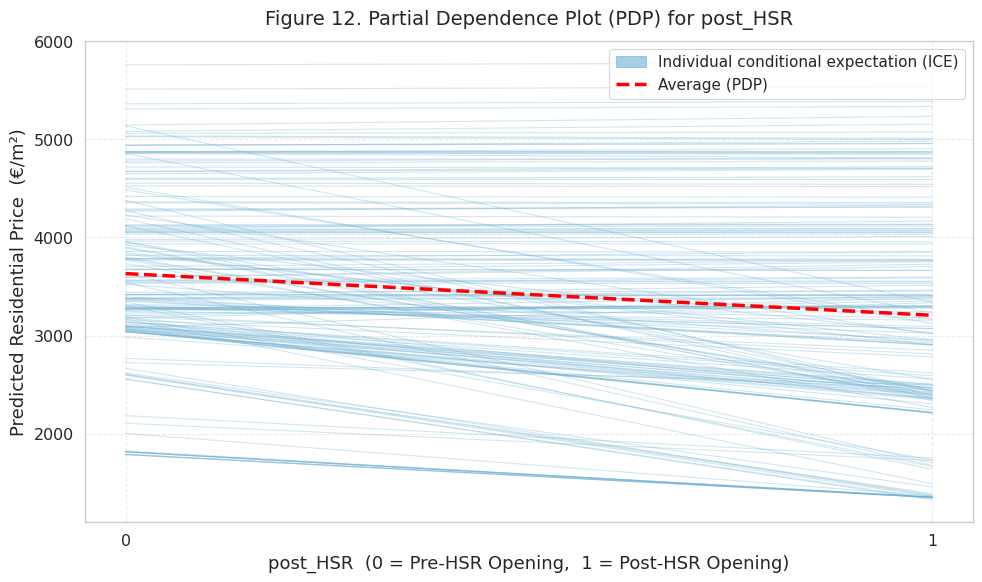

In [ ]:

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Pipeline
categorical_features = ['City', 'Station']
numeric_features = ['YEAR', 'post_HSR']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', SimpleImputer(strategy='median'), numeric_features)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
])

pipeline.fit(X_train, y_train)

# PDP
# جایگزین بخش PDP در Cell 15

fig, ax = plt.subplots(figsize=(10, 6))

pdp_result = PartialDependenceDisplay.from_estimator(
    pipeline, X_train, ['post_HSR'], grid_resolution=2, kind='both'
)
plt.close('all')

fig, ax = plt.subplots(figsize=(10, 6))

ice_vals = pdp_result.pd_results[0]['individual'][0]
x_vals = np.array([0, 1])

for i in range(len(ice_vals)):
    ax.plot(x_vals, ice_vals[i], color='#6aafd2', alpha=0.3, linewidth=0.8)

avg_vals = pdp_result.pd_results[0]['average'][0]
ax.plot(x_vals, avg_vals, color='red', linewidth=2.5, linestyle='--', label='average', zorder=5)

ax.set_xlabel('post_HSR  (0 = Pre-HSR Opening,  1 = Post-HSR Opening)', fontsize=13)
ax.set_ylabel('Predicted Residential Price  (€/m²)', fontsize=13)
ax.set_title('Figure 12. Partial Dependence Plot (PDP) for post_HSR', fontsize=14, pad=12)
ax.set_xticks([0, 1])
ax.grid(True, linestyle='--', alpha=0.4)

import matplotlib.patches as mpatches
ice_patch = mpatches.Patch(color='#6aafd2', alpha=0.6, label='Individual conditional expectation (ICE)')
avg_line = plt.Line2D([0],[0], color='red', linewidth=2.5, linestyle='--', label='Average (PDP)')
ax.legend(handles=[ice_patch, avg_line], fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('Figure12_PDP_post_HSR.png', dpi=300, bbox_inches='tight')
plt.show()